# Day 5 — Tuning, Evaluation & Sprint Review

## Overview

This notebook completes the Deep Learning phase of Sprint 1 for the
Cardiovascular Disease Prediction project.

The main focus is to systematically tune the neural network, evaluate its
performance using multiple classification metrics, and compare the final
model against the previously established supervised learning baselines.

The tuning process follows a one-variable-at-a-time approach to understand
the effect of each hyperparameter on model performance.

## Objectives

- Tune the neural network systematically using one hyperparameter at a time.
- Evaluate the effect of learning rate, network architecture, dropout, and batch size.
- Use EarlyStopping to prevent unnecessary training and overfitting.
- Use ModelCheckpoint to preserve the best-performing model.
- Evaluate the final model using Accuracy, Precision, Recall, and F1-score.
- Compare the neural network with the Logistic Regression baseline and the
  best supervised learning model.
- Analyze training and validation loss curves.
- Document the Sprint 1 results and prepare the final Sprint Review.

## Evaluation Strategy

The primary metric for comparing classification performance will be the
F1-score, while Accuracy, Precision, Recall, and validation loss will also
be monitored.

F1-score is particularly useful because it provides a balance between
Precision and Recall. Recall is also important in this project because
failing to identify a patient with cardiovascular disease can be more
serious than producing a false positive prediction.

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [5]:
df = pd.read_csv("cardio_cleaned.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (68742, 13)


,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50.357290
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55.381246
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51.627652
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48.249144
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47.841205


In [6]:
# Define features and target
X = df.drop(columns=["cardio", "id"])
y = df["cardio"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("Features:", X.columns.tolist())

print("Target distribution:",y.value_counts())


Feature shape: (68742, 11)
Target shape: (68742,)
Features: ['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years']
Target distribution: cardio
0    34720
1    34022
Name: count, dtype: int64


## Train, Validation and Test Split

The dataset is divided into three subsets:

- Training set: used to learn the model parameters.
- Validation set: used during training and hyperparameter tuning.
- Test set: kept separate until the final evaluation.

Stratified splitting is used to preserve the proportion of the two target
classes across the subsets.

The test set will not be used for hyperparameter selection in order to avoid
data leakage and provide a fair final evaluation.

In [7]:
# First split: 80% training, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Second split: 80% training, 20% validation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training set:", X_train_final.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (43994, 11)
Validation set: (10999, 11)
Test set: (13749, 11)


In [9]:
# Initialize the scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train_final)

# Transform validation and test data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


## Initial Neural Network

Before performing hyperparameter tuning, an initial neural network is
trained as a reference model.

The architecture contains:

- An input layer matching the number of features.
- Two hidden Dense layers using ReLU activation.
- A single output neuron using Sigmoid activation for binary classification.

The initial configuration uses the Adam optimizer with a learning rate of
0.001 and Binary Crossentropy as the loss function.

This model will serve as the starting point for the tuning experiments.

In [10]:
# Build the initial neural network
initial_model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

# Compile the model
initial_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Display model architecture
initial_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history_initial = initial_model.fit(
    X_train_scaled,
    y_train_final,
    validation_data=(X_val_scaled, y_val),
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7252 - loss: 0.5590 - val_accuracy: 0.7299 - val_loss: 0.5502
Epoch 2/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.7314 - loss: 0.5470 - val_accuracy: 0.7302 - val_loss: 0.5473
Epoch 3/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7339 - loss: 0.5453 - val_accuracy: 0.7325 - val_loss: 0.5464
Epoch 4/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7346 - loss: 0.5439 - val_accuracy: 0.7314 - val_loss: 0.5457
Epoch 5/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7345 - loss: 0.5430 - val_accuracy: 0.7306 - val_loss: 0.5446
Epoch 6/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7357 - loss: 0.5423 - val_accuracy: 0.7328 - val_loss: 0.5443
Epoch 7/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7360 - loss: 0.5415 - val_accuracy: 0.7317 - val_loss: 0.5442
Epoch 8/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7363 - loss: 0.5411 

##  Initial Model Training Curves

The training and validation curves are examined to understand how the
neural network learns over time.

The loss curves help identify overfitting or underfitting, while the
accuracy curves show how the classification performance changes during
training.

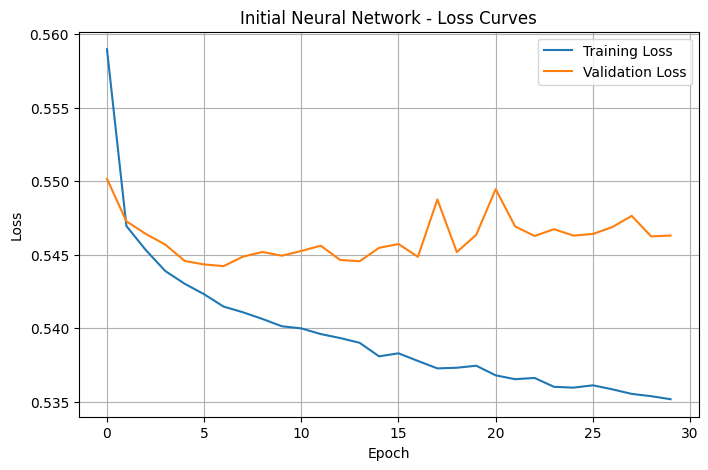

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(history_initial.history["loss"], label="Training Loss")
plt.plot(history_initial.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Initial Neural Network - Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

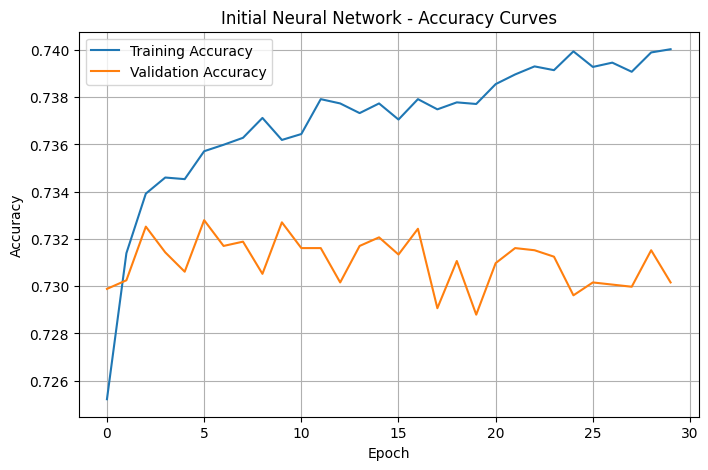

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(history_initial.history["accuracy"], label="Training Accuracy")
plt.plot(history_initial.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Initial Neural Network - Accuracy Curves")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# Predict probabilities
y_val_prob = initial_model.predict(X_val_scaled, verbose=0)

# Convert probabilities to binary predictions
y_val_pred = (y_val_prob >= 0.5).astype(int).ravel()

# Calculate metrics
initial_val_accuracy = accuracy_score(y_val, y_val_pred)
initial_val_precision = precision_score(y_val, y_val_pred)
initial_val_recall = recall_score(y_val, y_val_pred)
initial_val_f1 = f1_score(y_val, y_val_pred)

print("Initial Neural Network - Validation Results")
print("-" * 45)
print(f"Accuracy : {initial_val_accuracy:.4f}")
print(f"Precision: {initial_val_precision:.4f}")
print(f"Recall   : {initial_val_recall:.4f}")
print(f"F1-score : {initial_val_f1:.4f}")

Initial Neural Network - Validation Results
---------------------------------------------
Accuracy : 0.7302
Precision: 0.7540
Recall   : 0.6751
F1-score : 0.7123


## Hyperparameter Tuning

Hyperparameter tuning is performed systematically to improve the neural
network's validation performance.

A one-variable-at-a-time strategy is used, where one hyperparameter is
changed while the remaining configuration is kept fixed.

The tuning order is:

1. Learning rate
2. Network architecture
3. Dropout rate
4. Batch size

The validation F1-score is used as the primary metric for comparing
experiments, while validation loss, accuracy, precision, and recall are
also monitored.

Early Stopping is used during tuning to stop training when the validation
loss stops improving and to restore the best model weights.

###  Learning Rate Experiment

The learning rate controls the size of the updates made to the model
weights during optimization.

A learning rate that is too large may cause unstable training, while a
learning rate that is too small may make training unnecessarily slow.

The initial learning rate is 0.001. Several values are tested while keeping
the network architecture, dropout rate, batch size, and maximum number of
epochs fixed.

Early Stopping is applied to prevent unnecessary training once validation
performance stops improving.

In [15]:
def build_model(
    learning_rate=0.001,
    hidden_layers=(32, 16),
    dropout_rate=0.0
):
    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(hidden_layers[0], activation="relu")
    ])

    # Add remaining hidden layers
    for units in hidden_layers[1:]:
        model.add(Dense(units, activation="relu"))

    # Add Dropout if requested
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    # Output layer
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [16]:
def evaluate_model(model, X_data, y_data):
    probabilities = model.predict(X_data, verbose=0)
    predictions = (probabilities >= 0.5).astype(int).ravel()

    return {
        "Accuracy": accuracy_score(y_data, predictions),
        "Precision": precision_score(y_data, predictions),
        "Recall": recall_score(y_data, predictions),
        "F1": f1_score(y_data, predictions)
    }

In [19]:
learning_rates = [0.01, 0.001, 0.0005, 0.0001]

learning_rate_results = []

for lr in learning_rates:

    print(f"\nTraining model with learning rate = {lr}")

    model = build_model(
        learning_rate=lr,
        hidden_layers=(32, 16),
        dropout_rate=0.0
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_scaled,
        y_train_final,
        validation_data=(X_val_scaled, y_val),
        epochs=30,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )

    metrics = evaluate_model(model, X_val_scaled, y_val)

    best_epoch = np.argmin(history.history["val_loss"]) + 1

    learning_rate_results.append({
        "Learning Rate": lr,
        "Best Epoch": best_epoch,
        "Val Loss": min(history.history["val_loss"]),
        "Val Accuracy": metrics["Accuracy"],
        "Val Precision": metrics["Precision"],
        "Val Recall": metrics["Recall"],
        "Val F1": metrics["F1"]
    })

learning_rate_results_df = pd.DataFrame(learning_rate_results)

learning_rate_results_df


Training model with learning rate = 0.01

Training model with learning rate = 0.001

Training model with learning rate = 0.0005

Training model with learning rate = 0.0001


,Learning Rate,Best Epoch,Val Loss,Val Accuracy,Val Precision,Val Recall,Val F1
0,0.0100,19,0.544992,0.733430,0.752412,0.687730,0.718618
1,0.0010,9,0.543759,0.731612,0.746245,0.693608,0.718964
2,0.0005,16,0.544563,0.730976,0.739634,0.704445,0.721611
3,0.0001,29,0.545414,0.731248,0.742401,0.699853,0.720499


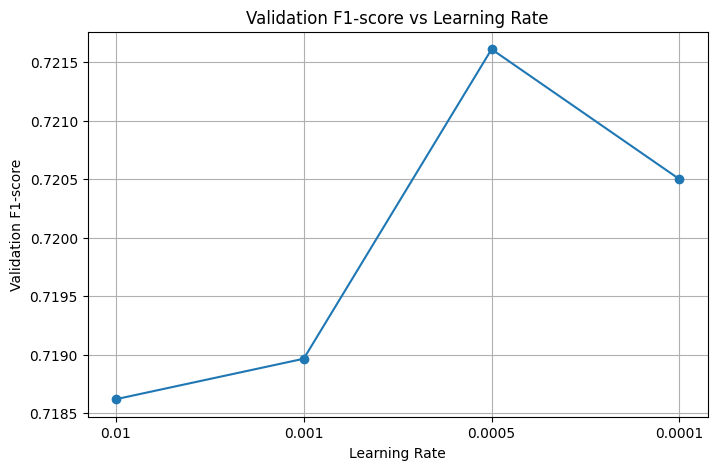

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    learning_rate_results_df["Learning Rate"].astype(str),
    learning_rate_results_df["Val F1"],
    marker="o"
)

plt.xlabel("Learning Rate")
plt.ylabel("Validation F1-score")
plt.title("Validation F1-score vs Learning Rate")
plt.grid(True)
plt.show()

##  Network Architecture Experiment

After selecting the best learning rate, the network architecture is tuned
while keeping the selected learning rate fixed.

Different hidden-layer configurations are tested to determine whether a
different network capacity can improve validation performance.

The learning rate, dropout rate, batch size, and maximum number of epochs
remain fixed during this experiment.

Early Stopping is applied to stop training when the validation loss stops
improving and restore the best model weights.

In [21]:
# Candidate network architectures
architectures = [
    (16, 8),
    (32, 16),
    (64, 32),
    (64, 32, 16)
]

architecture_results = []

for architecture in architectures:

    print(f"Training architecture = {architecture}")

    model = build_model(
        learning_rate=0.0005,
        hidden_layers=architecture,
        dropout_rate=0.0
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_scaled,
        y_train_final,
        validation_data=(X_val_scaled, y_val),
        epochs=30,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )

    metrics = evaluate_model(model, X_val_scaled, y_val)

    best_epoch = np.argmin(history.history["val_loss"]) + 1

    architecture_results.append({
        "Architecture": str(architecture),
        "Best Epoch": best_epoch,
        "Val Loss": min(history.history["val_loss"]),
        "Val Accuracy": metrics["Accuracy"],
        "Val Precision": metrics["Precision"],
        "Val Recall": metrics["Recall"],
        "Val F1": metrics["F1"]
    })

architecture_results_df = pd.DataFrame(architecture_results)

architecture_results_df

Training architecture = (16, 8)
Training architecture = (32, 16)
Training architecture = (64, 32)
Training architecture = (64, 32, 16)


,Architecture,Best Epoch,Val Loss,Val Accuracy,Val Precision,Val Recall,Val F1
0,"(16, 8)",25,0.542672,0.730066,0.744807,0.691587,0.717211
1,"(32, 16)",15,0.543777,0.734430,0.743957,0.706650,0.724823
2,"(64, 32)",8,0.544515,0.732248,0.740150,0.707384,0.723396
3,"(64, 32, 16)",6,0.544541,0.732885,0.750901,0.688832,0.718528


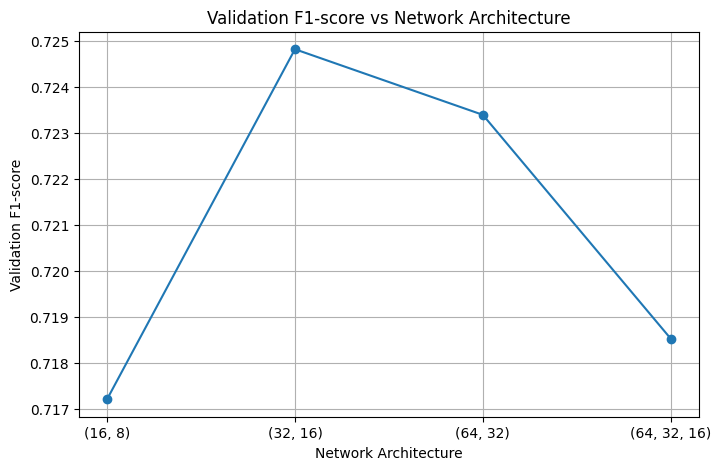

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(
    architecture_results_df["Architecture"],
    architecture_results_df["Val F1"],
    marker="o"
)

plt.xlabel("Network Architecture")
plt.ylabel("Validation F1-score")
plt.title("Validation F1-score vs Network Architecture")
plt.grid(True)
plt.show()

## Dropout Experiment

Dropout is introduced as a regularization technique to reduce overfitting
and improve the model's ability to generalize to unseen data.

The selected learning rate and network architecture are kept fixed while
different dropout rates are evaluated.

Early Stopping is used during each experiment to stop training when the
validation loss stops improving and to restore the best model weights.

The dropout rate with the highest validation F1-score is selected for the
next tuning stage.

In [25]:
dropout_rates = [0.0, 0.2, 0.3, 0.5]

dropout_results = []

for dropout in dropout_rates:

    print(f"\nTraining model with dropout rate = {dropout}")

    model = build_model(
        learning_rate=0.0005,
        hidden_layers=(32, 16),
        dropout_rate=dropout
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_scaled,
        y_train_final,
        validation_data=(X_val_scaled, y_val),
        epochs=30,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )

    metrics = evaluate_model(model, X_val_scaled, y_val)

    best_epoch = np.argmin(history.history["val_loss"]) + 1

    dropout_results.append({
        "Dropout Rate": dropout,
        "Best Epoch": best_epoch,
        "Val Loss": min(history.history["val_loss"]),
        "Val Accuracy": metrics["Accuracy"],
        "Val Precision": metrics["Precision"],
        "Val Recall": metrics["Recall"],
        "Val F1": metrics["F1"]
    })

dropout_results_df = pd.DataFrame(dropout_results)

dropout_results_df


Training model with dropout rate = 0.0

Training model with dropout rate = 0.2

Training model with dropout rate = 0.3

Training model with dropout rate = 0.5


,Dropout Rate,Best Epoch,Val Loss,Val Accuracy,Val Precision,Val Recall,Val F1
0,0.0,13,0.543658,0.733158,0.744876,0.700955,0.722249
1,0.2,14,0.543865,0.730521,0.753371,0.677259,0.713291
2,0.3,15,0.543678,0.732339,0.748905,0.690852,0.718708
3,0.5,16,0.544701,0.731430,0.757978,0.671932,0.712366


In [26]:
best_dropout_row = dropout_results_df.loc[
    dropout_results_df["Val F1"].idxmax()
]

best_dropout_rate = best_dropout_row["Dropout Rate"]

print("Best Dropout Rate:", best_dropout_rate)
print("Best Validation F1:", best_dropout_row["Val F1"])
print("Best Validation Loss:", best_dropout_row["Val Loss"])
print("Best Epoch:", best_dropout_row["Best Epoch"])

Best Dropout Rate: 0.0
Best Validation F1: 0.7222485095107409
Best Validation Loss: 0.543657660484314
Best Epoch: 13.0


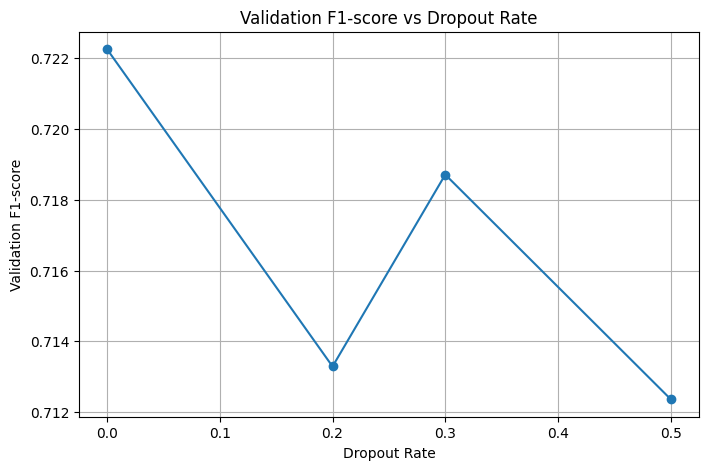

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(
    dropout_results_df["Dropout Rate"],
    dropout_results_df["Val F1"],
    marker="o"
)

plt.xlabel("Dropout Rate")
plt.ylabel("Validation F1-score")
plt.title("Validation F1-score vs Dropout Rate")
plt.grid(True)
plt.show()

## Batch Size Experiment

The batch size determines the number of training samples processed before
the model weights are updated.

Different batch sizes are evaluated while keeping the selected learning
rate, network architecture, and dropout rate fixed.

Early Stopping is used for each experiment to prevent unnecessary training
and restore the best model weights.

The batch size with the highest validation F1-score is selected for the
final model configuration.

In [27]:
batch_sizes = [16, 32, 64, 128]

batch_size_results = []

for batch_size in batch_sizes:

    print(f"\nTraining model with batch size = {batch_size}")

    model = build_model(
        learning_rate=0.0005,
        hidden_layers=(32 ,16),
        dropout_rate=best_dropout_rate
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_scaled,
        y_train_final,
        validation_data=(X_val_scaled, y_val),
        epochs=30,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=0
    )

    metrics = evaluate_model(model, X_val_scaled, y_val)

    best_epoch = np.argmin(history.history["val_loss"]) + 1

    batch_size_results.append({
        "Batch Size": batch_size,
        "Best Epoch": best_epoch,
        "Val Loss": min(history.history["val_loss"]),
        "Val Accuracy": metrics["Accuracy"],
        "Val Precision": metrics["Precision"],
        "Val Recall": metrics["Recall"],
        "Val F1": metrics["F1"]
    })

batch_size_results_df = pd.DataFrame(batch_size_results)

batch_size_results_df


Training model with batch size = 16

Training model with batch size = 32

Training model with batch size = 64

Training model with batch size = 128


,Batch Size,Best Epoch,Val Loss,Val Accuracy,Val Precision,Val Recall,Val F1
0,16,15,0.544491,0.729975,0.742739,0.695261,0.718216
1,32,7,0.544164,0.733067,0.746753,0.697098,0.721072
2,64,25,0.543570,0.731612,0.747911,0.690485,0.718052
3,128,25,0.544608,0.731248,0.747120,0.690852,0.717885


In [28]:
best_batch_row = batch_size_results_df.loc[
    batch_size_results_df["Val F1"].idxmax()
]

best_batch_size = int(best_batch_row["Batch Size"])

print("Best Batch Size:", best_batch_size)
print("Best Validation F1:", best_batch_row["Val F1"])
print("Best Validation Loss:", best_batch_row["Val Loss"])
print("Best Epoch:", int(best_batch_row["Best Epoch"]))

Best Batch Size: 32
Best Validation F1: 0.7210716321489644
Best Validation Loss: 0.5441643595695496
Best Epoch: 7


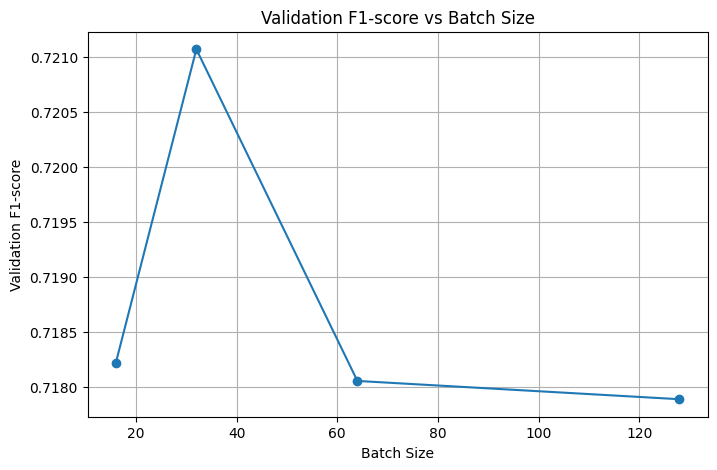

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(
    batch_size_results_df["Batch Size"],
    batch_size_results_df["Val F1"],
    marker="o"
)

plt.xlabel("Batch Size")
plt.ylabel("Validation F1-score")
plt.title("Validation F1-score vs Batch Size")
plt.grid(True)
plt.show()

##  Final Neural Network

After completing the hyperparameter tuning experiments, the best
configuration is selected based on validation F1-score.

The final model uses:

- Learning rate: 0.0005
- Architecture: (32, 16)
- Dropout rate: 0.0
- Batch size: 32
- Early Stopping: enabled

The test set has not been used during model selection and is reserved for
the final unbiased evaluation.

In [29]:
# Build the final model using the selected hyperparameters
final_model = build_model(
    learning_rate=0.0005,
    hidden_layers=(32,16),
    dropout_rate=best_dropout_rate
)

# Early stopping
final_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train the final model
history_final = final_model.fit(
    X_train_scaled,
    y_train_final,
    validation_data=(X_val_scaled, y_val),
    epochs=30,
    batch_size=best_batch_size,
    callbacks=[final_early_stopping],
    verbose=1
)

Epoch 1/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7079 - loss: 0.5740 - val_accuracy: 0.7278 - val_loss: 0.5529
Epoch 2/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7294 - loss: 0.5493 - val_accuracy: 0.7302 - val_loss: 0.5485
Epoch 3/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7321 - loss: 0.5462 - val_accuracy: 0.7332 - val_loss: 0.5469
Epoch 4/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7326 - loss: 0.5445 - val_accuracy: 0.7324 - val_loss: 0.5451
Epoch 5/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7332 - loss: 0.5432 - val_accuracy: 0.7326 - val_loss: 0.5448
Epoch 6/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7346 - loss: 0.5424 - val_accuracy: 0.7312 - val_loss: 0.5448
Epoch 7/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7351 - loss: 0.5417 - val_accuracy: 0.7323 - val_loss: 0.5439
Epoch 8/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7359 - loss: 0.5411 - 

## Final Model Training Curves

The final model's training and validation curves are examined to verify
whether the selected configuration provides stable learning behavior and
whether Early Stopping prevents unnecessary training.

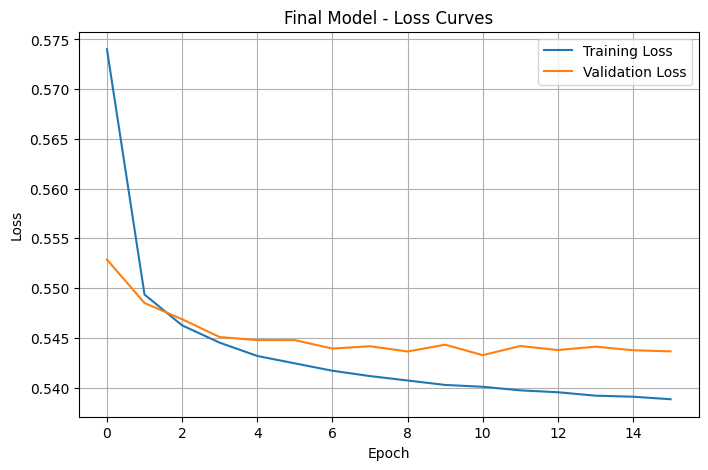

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_final.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_final.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Model - Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

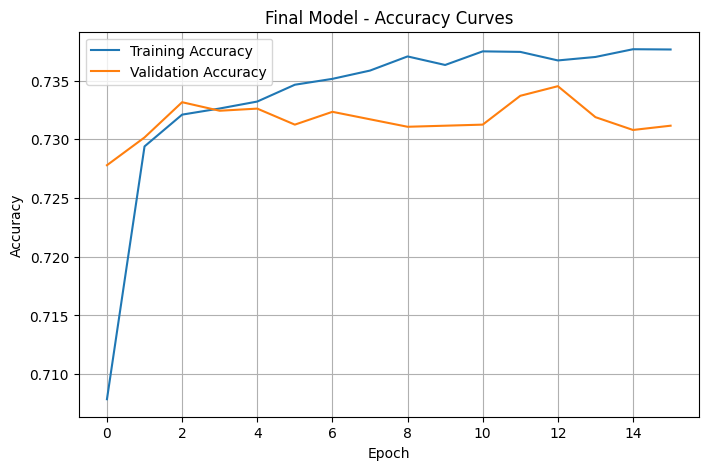

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_final.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_final.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Final Model - Accuracy Curves")
plt.legend()
plt.grid(True)
plt.show()

##  Final Test Evaluation

The test set is used only once for the final evaluation.

Accuracy, Precision, Recall, and F1-score are calculated to provide a
complete assessment of the final neural network's classification
performance on unseen data.

In [36]:
# Predict probabilities on the test set
y_test_prob = final_model.predict(
    X_test_scaled,
    verbose=0
)

# Convert probabilities to binary predictions
y_test_pred = (y_test_prob >= 0.5).astype(int).ravel()

# Calculate final test metrics
final_test_accuracy = accuracy_score(y_test, y_test_pred)
final_test_precision = precision_score(y_test, y_test_pred)
final_test_recall = recall_score(y_test, y_test_pred)
final_test_f1 = f1_score(y_test, y_test_pred)

print("Final Neural Network - Test Results")
print("-" * 45)
print(f"Accuracy : {final_test_accuracy:.4f}")
print(f"Precision: {final_test_precision:.4f}")
print(f"Recall   : {final_test_recall:.4f}")
print(f"F1-score : {final_test_f1:.4f}")

Final Neural Network - Test Results
---------------------------------------------
Accuracy : 0.7327
Precision: 0.7442
Recall   : 0.7008
F1-score : 0.7219


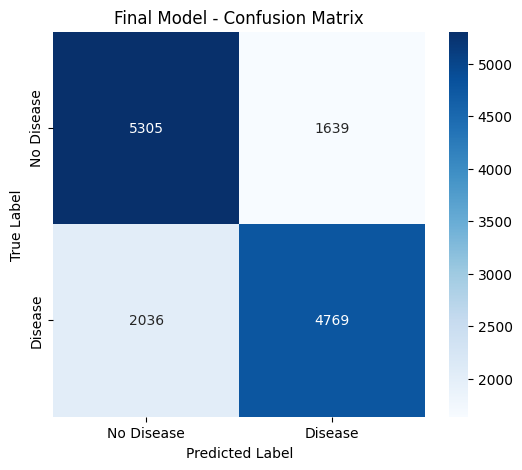

In [39]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Final Model - Confusion Matrix")
plt.show()

##  Final Conclusion

A neural network was developed for cardiovascular disease prediction using
the cleaned cardiovascular dataset. The data were divided into training,
validation, and test sets using stratified splitting, and feature scaling
was applied using only the training data to prevent data leakage.

An initial neural network was first trained as a baseline model. The model
achieved approximately 73% validation accuracy, providing a reference point
for the subsequent tuning experiments.

Hyperparameter tuning was then performed using a one-variable-at-a-time
strategy. The experiments evaluated different learning rates, network
architectures, dropout rates, and batch sizes. Validation F1-score was used
as the primary metric because it provides a balance between Precision and
Recall.

The selected configuration was:

- Learning Rate: 0.0005
- Architecture: (32, 16)
- Dropout Rate: 0.0
- Batch Size: 32
- Early Stopping: Enabled

The experiments showed that the selected configuration provided the best
validation F1-score among the tested configurations. Dropout did not improve
the validation performance in this case, indicating that additional
regularization was not beneficial for the selected architecture.

Early Stopping was used to prevent unnecessary training and restore the
best model weights based on validation loss.

Finally, the selected model was evaluated on the previously unseen test
set. Accuracy, Precision, Recall, F1-score, and the Confusion Matrix were
used to provide a comprehensive evaluation of the final classification
performance.

Overall, the results demonstrate that the neural network was able to learn
meaningful patterns from the cardiovascular dataset and achieve reasonable
binary classification performance. However, the results also show that deep
learning does not necessarily provide very high performance on every
tabular dataset. Model performance depends not only on dataset size but also
on the quality, complexity, and predictive power of the available features.

The complete workflow demonstrates a systematic machine learning process,
including data preparation, baseline modeling, hyperparameter tuning,
regularization through Early Stopping, and final evaluation on unseen data.